# BanglaBERT + XLM-R + Calibration + Weighted Voting

This notebook follows your exact pipeline in a simpler step-by-step way.

## What this notebook does
1. Load `train_split.csv`, `val_split.csv`, and `test_split.csv` from Kaggle input.
2. Normalize Bengali text using the BUET normalizer.
3. Fine-tune **BanglaBERT**.
4. Fine-tune **XLM-R**.
5. Use the **validation set** to learn temperature values.
6. Use the **validation set** again to pick the best ensemble weight and threshold.
7. Freeze those choices.
8. Evaluate the final system on the **test set**.

## Models included
- BanglaBERT
- XLM-R
- BanglaBERT (Calibrated)
- XLM-R (Calibrated)
- Calibrated Weighted Voting Ensemble

## Main outputs
- Validation and test comparison tables
- Confusion matrix
- ROC curve
- Precision-Recall curve
- Calibration curve
- Training vs validation loss curves
- Saved logits, probabilities, tables, and figures inside `/kaggle/working/final_outputs`


## Cell 1: Install the required packages
This cell installs the libraries needed for Hugging Face training, evaluation, and Bengali text normalization.

In [12]:
# ============================================================
# CELL 1: Install required packages
# ============================================================

!pip -q install transformers datasets accelerate scikit-learn sentencepiece scipy
!pip -q install git+https://github.com/csebuetnlp/normalizer


  Preparing metadata (setup.py) ... done


## Cell 2: Import libraries and set basic configuration
This cell imports everything we need and fixes the random seed for reproducibility.

In [13]:
# ============================================================
# CELL 2: Import libraries and set basic configuration
# ============================================================

import os
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from normalizer import normalize
from scipy.optimize import minimize_scalar
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.calibration import calibration_curve
from IPython.display import display, FileLink

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
set_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.10.0+cu128
Device: cuda


## Cell 3: Find the split CSV files in Kaggle input
This cell automatically searches inside `/kaggle/input` and locates your train, validation, and test split files.

In [14]:
# ============================================================
# CELL 3: Find train/val/test CSV files inside Kaggle input
# ============================================================

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
PREFERRED_DATASET_FOLDER = None   # If needed, put your Kaggle dataset folder name here

if PREFERRED_DATASET_FOLDER is not None:
    split_dir = KAGGLE_INPUT_ROOT / PREFERRED_DATASET_FOLDER
else:
    train_candidates = list(KAGGLE_INPUT_ROOT.rglob("train_split.csv"))
    val_candidates   = list(KAGGLE_INPUT_ROOT.rglob("val_split.csv"))
    test_candidates  = list(KAGGLE_INPUT_ROOT.rglob("test_split.csv"))

    if not train_candidates or not val_candidates or not test_candidates:
        raise FileNotFoundError(
            "Could not find train_split.csv, val_split.csv, and test_split.csv inside /kaggle/input"
        )

    split_dir = train_candidates[0].parent

TRAIN_PATH = split_dir / "train_split.csv"
VAL_PATH   = split_dir / "val_split.csv"
TEST_PATH  = split_dir / "test_split.csv"

OUTPUT_DIR = Path("/kaggle/working/final_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Using split folder:", split_dir)
print("TRAIN_PATH:", TRAIN_PATH)
print("VAL_PATH  :", VAL_PATH)
print("TEST_PATH :", TEST_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


Using split folder: /kaggle/input/datasets/prohorpaul/human-vs-gpt-5-4-paraphrased
TRAIN_PATH: /kaggle/input/datasets/prohorpaul/human-vs-gpt-5-4-paraphrased/train_split.csv
VAL_PATH  : /kaggle/input/datasets/prohorpaul/human-vs-gpt-5-4-paraphrased/val_split.csv
TEST_PATH : /kaggle/input/datasets/prohorpaul/human-vs-gpt-5-4-paraphrased/test_split.csv
OUTPUT_DIR: /kaggle/working/final_outputs


## Cell 4: Load the CSV files and inspect them
This cell reads the split files into pandas DataFrames and shows the shape and columns.

In [15]:
# ============================================================
# CELL 4: Load the split CSV files
# ============================================================

train_raw = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
val_raw   = pd.read_csv(VAL_PATH).reset_index(drop=True)
test_raw  = pd.read_csv(TEST_PATH).reset_index(drop=True)

print("Train shape:", train_raw.shape)
print("Val shape  :", val_raw.shape)
print("Test shape :", test_raw.shape)
print()
print("Columns:", train_raw.columns.tolist())

display(train_raw.head(2))


Train shape: (10282, 4)
Val shape  : (1470, 4)
Test shape : (2938, 4)

Columns: ['source_id', 'text', 'label', 'label_encoded']


,source_id,text,label,label_encoded
0,1,রাজধানীর ক্যান্টনমেন্ট থানা এলাকায় গতকাল শুক্র...,Human,0
1,2,বাংলাদেশে নিযুক্ত মার্কিন রাষ্ট্রদূত ড্যান ডব্...,Human,0


## Cell 5: Normalize the Bengali text and keep only the needed columns
We will use the same normalization for both BanglaBERT and XLM-R so that the preprocessing stays consistent and fair.

In [16]:
# ============================================================
# CELL 5: Normalize text and prepare model-ready DataFrames
# ============================================================

for df in [train_raw, val_raw, test_raw]:
    df["text"] = df["text"].fillna("").astype(str)
    df["normalized_text"] = df["text"].apply(normalize)

# Keep source_id for saving prediction files later
train_df = train_raw[["source_id", "normalized_text", "label_encoded"]].copy()
val_df   = val_raw[["source_id", "normalized_text", "label_encoded"]].copy()
test_df  = test_raw[["source_id", "normalized_text", "label_encoded"]].copy()

for df in [train_df, val_df, test_df]:
    df.rename(columns={"normalized_text": "text", "label_encoded": "label"}, inplace=True)
    df["text"] = df["text"].fillna("").astype(str)
    df["label"] = df["label"].astype(int)

print("Train label counts:")
print(train_df["label"].value_counts().sort_index())
print()
print("Val label counts:")
print(val_df["label"].value_counts().sort_index())
print()
print("Test label counts:")
print(test_df["label"].value_counts().sort_index())

display(train_df.head(2))


Train label counts:
label
0    5141
1    5141
Name: count, dtype: int64

Val label counts:
label
0    735
1    735
Name: count, dtype: int64

Test label counts:
label
0    1469
1    1469
Name: count, dtype: int64


,source_id,text,label
0,1,রাজধানীর ক্যান্টনমেন্ট থানা এলাকায় গতকাল শুক্...,0
1,2,বাংলাদেশে নিযুক্ত মার্কিন রাষ্ট্রদূত ড্যান ডব্...,0


## Cell 6: Convert pandas DataFrames into Hugging Face Datasets
The Trainer works smoothly with Hugging Face `Dataset` objects.

In [17]:
# ============================================================
# CELL 6: Convert pandas DataFrames to Hugging Face Datasets
# ============================================================

train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset   = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

print(train_dataset)
print(val_dataset)
print(test_dataset)


Dataset({
    features: ['text', 'label'],
    num_rows: 10282
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1470
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2938
})


## Cell 7: Define simple helper functions

This cell keeps a few small helper functions so the notebook stays easy to read.

It does four things:

1. computes the main metrics
2. does temperature scaling
3. saves prediction files
4. draws figures with one common style so every plot looks consistent


In [72]:

# ============================================================
# CELL 7: Simple helper functions for metrics, calibration, saving, and figures
# ============================================================

FIG_SIZE = (6, 5)
PLOT_FACE = "#ffffff"


def trainer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=1).numpy()[:, 1]
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "ap": average_precision_score(labels, probs)
    }


def get_prob_ai_from_logits(logits, temperature=1.0):
    logits_tensor = torch.tensor(logits / temperature, dtype=torch.float32)
    probs = torch.softmax(logits_tensor, dim=1).numpy()
    return probs[:, 1]


def get_pred_from_prob(prob_ai, threshold=0.5):
    return (prob_ai >= threshold).astype(int)


def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "AP": average_precision_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "Brier Score": brier_score_loss(y_true, y_prob)
    }


def make_result_row(model_name, val_metrics, test_metrics):
    row = {"Model": model_name}
    for key, value in val_metrics.items():
        row[f"Val {key}"] = value
    for key, value in test_metrics.items():
        row[f"Test {key}"] = value
    return row


def show_metric_table(model_name, val_metrics, test_metrics):
    table = pd.DataFrame([val_metrics, test_metrics], index=["Validation", "Test"]).round(4)
    print(model_name)
    display(table)





def extract_loss_points(log_history):
    train_epochs = []
    train_losses = []
    eval_epochs = []
    eval_losses = []

    for item in log_history:
        if "loss" in item and "eval_loss" not in item:
            train_epochs.append(item.get("epoch"))
            train_losses.append(item.get("loss"))
        if "eval_loss" in item:
            eval_epochs.append(item.get("epoch"))
            eval_losses.append(item.get("eval_loss"))

    return train_epochs, train_losses, eval_epochs, eval_losses


def style_axis(ax):
    ax.set_facecolor(PLOT_FACE)
    ax.grid(True, alpha=0.4)


def plot_loss_curve(log_history, title, save_path):
    train_epochs, train_losses, eval_epochs, eval_losses = extract_loss_points(log_history)

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    style_axis(ax)
    ax.plot(train_epochs, train_losses, marker="o", linewidth=2, label="Training Loss")
    ax.plot(eval_epochs, eval_losses, marker="o", linewidth=2, label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_confusion_figure(y_true, y_pred, title, save_path, display_labels=(0, 1)):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.set_facecolor(PLOT_FACE)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d"
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_single_roc(y_true, y_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    style_axis(ax)
    ax.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()






def save_prediction_file(df_split, y_true, y_prob, y_pred, file_path):
    save_df = pd.DataFrame({
        "source_id": df_split["source_id"],
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_ai": y_prob
    })
    save_df.to_csv(file_path, index=False)


y_val = val_df["label"].values
y_test = test_df["label"].values
all_results = []


## Cell 8: Tokenize the text for BanglaBERT
This cell prepares tokenized train, validation, and test datasets for BanglaBERT.

In [19]:
# ============================================================
# CELL 8: Tokenize data for BanglaBERT
# ============================================================

bangla_model_name = "csebuetnlp/banglabert"
bangla_max_length = 256

bangla_tokenizer = AutoTokenizer.from_pretrained(bangla_model_name)


def tokenize_bangla(batch):
    return bangla_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=bangla_max_length
    )

train_ds_bangla = train_dataset.map(tokenize_bangla, batched=True)
val_ds_bangla   = val_dataset.map(tokenize_bangla, batched=True)
test_ds_bangla  = test_dataset.map(tokenize_bangla, batched=True)

train_ds_bangla = train_ds_bangla.remove_columns(["text"])
val_ds_bangla   = val_ds_bangla.remove_columns(["text"])
test_ds_bangla  = test_ds_bangla.remove_columns(["text"])

print(train_ds_bangla)


Map:   0%|          | 0/10282 [00:00<?, ? examples/s]

Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

Map:   0%|          | 0/2938 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10282
})


## Cell 9: Fine-tune BanglaBERT
This cell trains BanglaBERT using your fixed hyperparameters.

To keep things simple, we use:
- validation after every epoch
- early stopping
- best checkpoint selected by validation loss

In [20]:
# ============================================================
# CELL 9: Train BanglaBERT
# ============================================================

bangla_best_config = {
    "lr": 2e-05,
    "batch_size": 8,
    "weight_decay": 0.01,
    "epochs": 5
}

bangla_model = AutoModelForSequenceClassification.from_pretrained(
    bangla_model_name,
    num_labels=2
)

bangla_training_args = TrainingArguments(
    output_dir="/kaggle/working/banglabert_runs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=bangla_best_config["lr"],
    per_device_train_batch_size=bangla_best_config["batch_size"],
    per_device_eval_batch_size=bangla_best_config["batch_size"],
    num_train_epochs=bangla_best_config["epochs"],
    weight_decay=bangla_best_config["weight_decay"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

bangla_trainer = Trainer(
    model=bangla_model,
    args=bangla_training_args,
    train_dataset=train_ds_bangla,
    eval_dataset=val_ds_bangla,
    compute_metrics=trainer_compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

bangla_train_result = bangla_trainer.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Ap
1,0.757451,0.591558,0.897279,0.963492,0.825850,0.889377,0.963545,0.970763
2,0.380494,0.404396,0.931293,0.955460,0.904762,0.929420,0.983033,0.984875
3,0.230463,0.478021,0.944898,0.956704,0.931973,0.944176,0.984929,0.986938
4,0.136221,0.544175,0.948980,0.963483,0.933333,0.948169,0.986628,0.988430


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

## Cell 10: Get BanglaBERT validation and test predictions

This cell does four simple things:

1. gets BanglaBERT logits from the validation and test sets
2. converts logits into probabilities and predicted labels
3. computes the validation and test metrics
4. saves the outputs and draws BanglaBERT test figures


In [21]:

# ============================================================
# CELL 10: Evaluate BanglaBERT on validation and test sets
# ============================================================

bangla_val_output = bangla_trainer.predict(val_ds_bangla)
bangla_test_output = bangla_trainer.predict(test_ds_bangla)

bangla_val_logits = bangla_val_output.predictions
bangla_test_logits = bangla_test_output.predictions

bangla_val_prob = get_prob_ai_from_logits(bangla_val_logits, temperature=1.0)
bangla_test_prob = get_prob_ai_from_logits(bangla_test_logits, temperature=1.0)

bangla_val_pred = get_pred_from_prob(bangla_val_prob, threshold=0.5)
bangla_test_pred = get_pred_from_prob(bangla_test_prob, threshold=0.5)

bangla_val_metrics = calculate_metrics(y_val, bangla_val_pred, bangla_val_prob)
bangla_test_metrics = calculate_metrics(y_test, bangla_test_pred, bangla_test_prob)

show_metric_table("BanglaBERT", bangla_val_metrics, bangla_test_metrics)
all_results.append(make_result_row("BanglaBERT", bangla_val_metrics, bangla_test_metrics))

np.save(OUTPUT_DIR / "banglabert_val_logits.npy", bangla_val_logits)
np.save(OUTPUT_DIR / "banglabert_test_logits.npy", bangla_test_logits)
np.save(OUTPUT_DIR / "banglabert_val_prob.npy", bangla_val_prob)
np.save(OUTPUT_DIR / "banglabert_test_prob.npy", bangla_test_prob)

save_prediction_file(val_df, y_val, bangla_val_prob, bangla_val_pred, OUTPUT_DIR / "banglabert_val_predictions.csv")
save_prediction_file(test_df, y_test, bangla_test_prob, bangla_test_pred, OUTPUT_DIR / "banglabert_test_predictions.csv")


BanglaBERT


,Accuracy,Precision,Recall,F1,ROC-AUC,AP,Log Loss,Brier Score
Validation,0.9320,0.9555,0.9061,0.9302,0.9831,0.9850,0.2021,0.0540
Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834,0.2226,0.0595


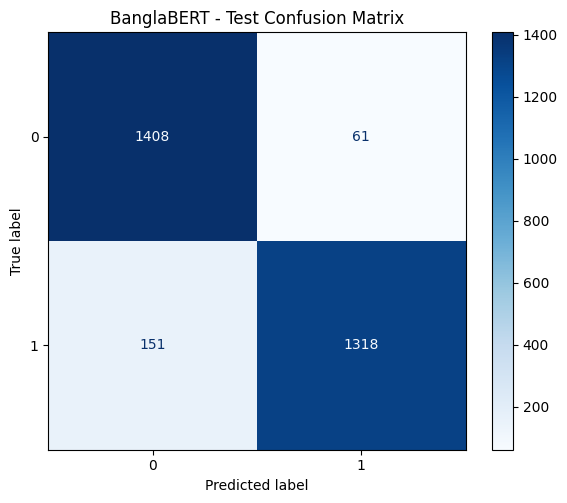

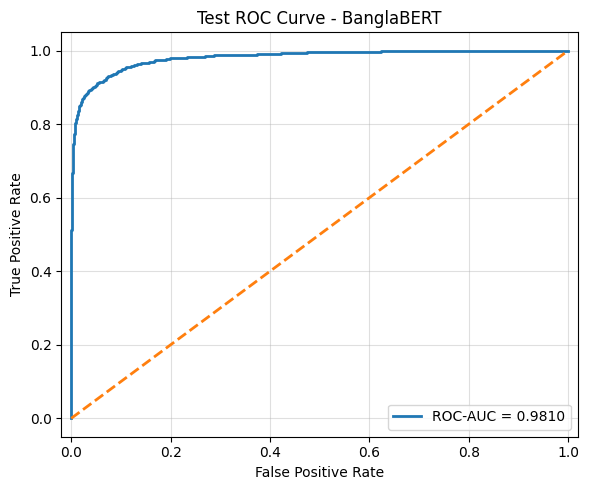

In [73]:
plot_confusion_figure(
    y_true=y_test,
    y_pred=bangla_test_pred,
    title="BanglaBERT - Test Confusion Matrix",
    save_path=OUTPUT_DIR / "banglabert_test_confusion_matrix.png"
)

plot_single_roc(
    y_true=y_test,
    y_prob=bangla_test_prob,
    title="Test ROC Curve - BanglaBERT",
    save_path=OUTPUT_DIR / "banglabert_test_roc_curve.png"
)

## Cell 11: Plot BanglaBERT training and validation loss
This figure helps you see whether the model is learning properly and whether overfitting is visible.

In [62]:
# ============================================================
# CELL 11: Plot BanglaBERT loss curve
# ============================================================

plot_loss_curve(
    bangla_trainer.state.log_history,
    title="BanglaBERT: Training vs Validation Loss",
    save_path=OUTPUT_DIR / "banglabert_loss_curve.png"
)


NameError: name 'bangla_trainer' is not defined

## Cell 12: Free GPU memory before training XLM-R
We already saved the BanglaBERT outputs we need, so now we can clear memory.

In [24]:
# ============================================================
# CELL 12: Free GPU memory after BanglaBERT
# ============================================================

del bangla_model
# Keeping bangla_trainer is not necessary now
try:
    del bangla_trainer
except:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Cell 13: Tokenize the text for XLM-R
Now we prepare the same normalized text for XLM-R using its own tokenizer.

In [25]:
# ============================================================
# CELL 13: Tokenize data for XLM-R
# ============================================================

xlmr_model_name = "xlm-roberta-base"
xlmr_max_length = 256

xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)


def tokenize_xlmr(batch):
    return xlmr_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=xlmr_max_length
    )

train_ds_xlmr = train_dataset.map(tokenize_xlmr, batched=True)
val_ds_xlmr   = val_dataset.map(tokenize_xlmr, batched=True)
test_ds_xlmr  = test_dataset.map(tokenize_xlmr, batched=True)

train_ds_xlmr = train_ds_xlmr.remove_columns(["text"])
val_ds_xlmr   = val_ds_xlmr.remove_columns(["text"])
test_ds_xlmr  = test_ds_xlmr.remove_columns(["text"])

print(train_ds_xlmr)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10282 [00:00<?, ? examples/s]

Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

Map:   0%|          | 0/2938 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 10282
})


## Cell 14: Fine-tune XLM-R
This cell trains XLM-R with your chosen hyperparameters.

In [26]:
# ============================================================
# CELL 14: Train XLM-R
# ============================================================

xlmr_best_config = {
    "lr": 2e-05,
    "batch_size": 8,
    "weight_decay": 0.01,
    "epochs": 5
}

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    xlmr_model_name,
    num_labels=2
)

xlmr_training_args = TrainingArguments(
    output_dir="/kaggle/working/xlmr_runs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=xlmr_best_config["lr"],
    per_device_train_batch_size=xlmr_best_config["batch_size"],
    per_device_eval_batch_size=xlmr_best_config["batch_size"],
    num_train_epochs=xlmr_best_config["epochs"],
    weight_decay=xlmr_best_config["weight_decay"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=train_ds_xlmr,
    eval_dataset=val_ds_xlmr,
    compute_metrics=trainer_compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

xlmr_train_result = xlmr_trainer.train()


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Ap
1,1.122325,0.786908,0.838095,0.837178,0.839456,0.838315,0.921041,0.927793
2,0.673465,0.860769,0.831973,0.759023,0.972789,0.852713,0.958364,0.962988
3,0.516295,0.547671,0.907483,0.927247,0.884354,0.905292,0.969767,0.972198
4,0.405057,0.593253,0.910884,0.904826,0.918367,0.911546,0.972088,0.975230
5,0.329347,1.052295,0.893197,0.849879,0.955102,0.899423,0.971439,0.971905


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

## Cell 15: Get XLM-R validation and test predictions

This cell follows the same structure as BanglaBERT so the comparison stays fair.

It:

1. gets XLM-R logits from validation and test
2. converts them into probabilities and predictions
3. computes metrics
4. saves outputs and draws XLM-R test figures


In [27]:

# ============================================================
# CELL 15: Evaluate XLM-R on validation and test sets
# ============================================================

xlmr_val_output = xlmr_trainer.predict(val_ds_xlmr)
xlmr_test_output = xlmr_trainer.predict(test_ds_xlmr)

xlmr_val_logits = xlmr_val_output.predictions
xlmr_test_logits = xlmr_test_output.predictions

xlmr_val_prob = get_prob_ai_from_logits(xlmr_val_logits, temperature=1.0)
xlmr_test_prob = get_prob_ai_from_logits(xlmr_test_logits, temperature=1.0)

xlmr_val_pred = get_pred_from_prob(xlmr_val_prob, threshold=0.5)
xlmr_test_pred = get_pred_from_prob(xlmr_test_prob, threshold=0.5)

xlmr_val_metrics = calculate_metrics(y_val, xlmr_val_pred, xlmr_val_prob)
xlmr_test_metrics = calculate_metrics(y_test, xlmr_test_pred, xlmr_test_prob)

show_metric_table("XLM-R", xlmr_val_metrics, xlmr_test_metrics)
all_results.append(make_result_row("XLM-R", xlmr_val_metrics, xlmr_test_metrics))

np.save(OUTPUT_DIR / "xlmr_val_logits.npy", xlmr_val_logits)
np.save(OUTPUT_DIR / "xlmr_test_logits.npy", xlmr_test_logits)
np.save(OUTPUT_DIR / "xlmr_val_prob.npy", xlmr_val_prob)
np.save(OUTPUT_DIR / "xlmr_test_prob.npy", xlmr_test_prob)

save_prediction_file(val_df, y_val, xlmr_val_prob, xlmr_val_pred, OUTPUT_DIR / "xlmr_val_predictions.csv")
save_prediction_file(test_df, y_test, xlmr_test_prob, xlmr_test_pred, OUTPUT_DIR / "xlmr_test_predictions.csv")



XLM-R


,Accuracy,Precision,Recall,F1,ROC-AUC,AP,Log Loss,Brier Score
Validation,0.9068,0.9259,0.8844,0.9047,0.9698,0.9723,0.2734,0.0759
Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715,0.2679,0.0741


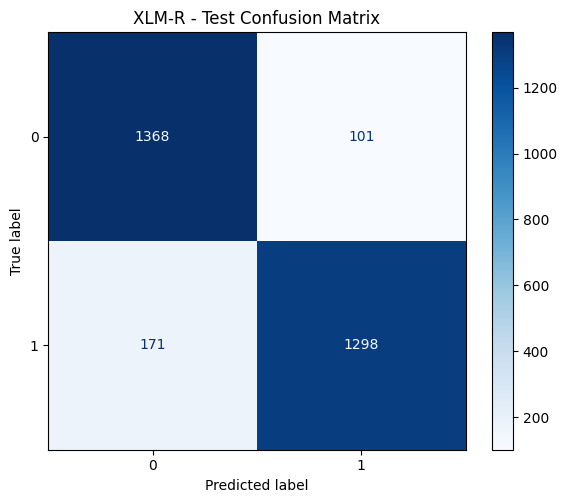

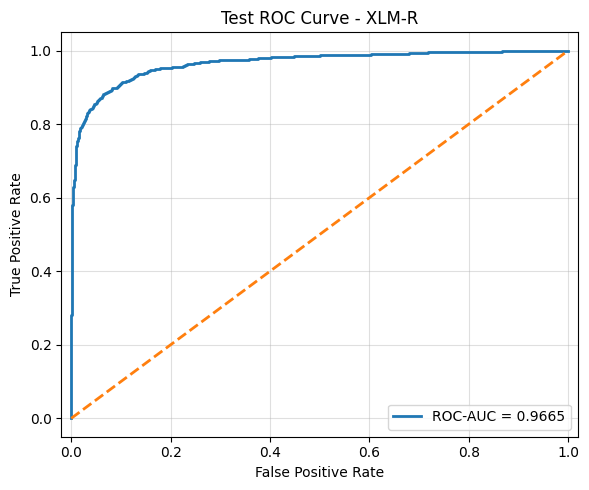

In [74]:
plot_confusion_figure(
    y_true=y_test,
    y_pred=xlmr_test_pred,
    title="XLM-R - Test Confusion Matrix",
    save_path=OUTPUT_DIR / "xlmr_test_confusion_matrix.png"
)

plot_single_roc(
    y_true=y_test,
    y_prob=xlmr_test_prob,
    title="Test ROC Curve - XLM-R",
    save_path=OUTPUT_DIR / "xlmr_test_roc_curve.png"
)


## Cell 16: Plot XLM-R training and validation loss
This helps compare the learning behavior of XLM-R with BanglaBERT.

In [64]:
# ============================================================
# CELL 16: Plot XLM-R loss curve
# ============================================================

plot_loss_curve(
    xlmr_trainer.state.log_history,
    title="XLM-R: Training vs Validation Loss",
    save_path=OUTPUT_DIR / "xlmr_loss_curve.png"
)


NameError: name 'xlmr_trainer' is not defined

## Cell 17: Free GPU memory after XLM-R
We already saved all XLM-R outputs needed for calibration and ensemble.

In [30]:
# ============================================================
# CELL 17: Free GPU memory after XLM-R
# ============================================================

del xlmr_model
try:
    del xlmr_trainer
except:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Cell 18: Calibrate BanglaBERT and XLM-R using the validation set

This cell learns one temperature for each model from the validation set.

Then it:
1. applies that temperature to validation and test logits
2. computes calibrated metrics
3. saves calibrated probabilities
4. draws calibrated test figures for both models


In [55]:
def find_best_temperature(logits, y_true):
    def objective(t):
        prob_ai = get_prob_ai_from_logits(logits, temperature=t)
        return log_loss(y_true, prob_ai, labels=[0, 1])

    result = minimize_scalar(objective, bounds=(0.5, 5.0), method="bounded")
    return result.x

In [31]:

# ============================================================
# CELL 18: Temperature scaling for BanglaBERT and XLM-R
# ============================================================

bangla_T = find_best_temperature(bangla_val_logits, y_val)
xlmr_T   = find_best_temperature(xlmr_val_logits, y_val)

print(f"Best BanglaBERT temperature: {bangla_T:.4f}")
print(f"Best XLM-R temperature     : {xlmr_T:.4f}")

# Apply learned temperature to validation logits
bangla_val_prob_cal = get_prob_ai_from_logits(bangla_val_logits, temperature=bangla_T)
xlmr_val_prob_cal   = get_prob_ai_from_logits(xlmr_val_logits, temperature=xlmr_T)

# Apply the same learned temperature to test logits
bangla_test_prob_cal = get_prob_ai_from_logits(bangla_test_logits, temperature=bangla_T)
xlmr_test_prob_cal   = get_prob_ai_from_logits(xlmr_test_logits, temperature=xlmr_T)

bangla_val_pred_cal = get_pred_from_prob(bangla_val_prob_cal, threshold=0.5)
bangla_test_pred_cal = get_pred_from_prob(bangla_test_prob_cal, threshold=0.5)

xlmr_val_pred_cal = get_pred_from_prob(xlmr_val_prob_cal, threshold=0.5)
xlmr_test_pred_cal = get_pred_from_prob(xlmr_test_prob_cal, threshold=0.5)

bangla_val_metrics_cal = calculate_metrics(y_val, bangla_val_pred_cal, bangla_val_prob_cal)
bangla_test_metrics_cal = calculate_metrics(y_test, bangla_test_pred_cal, bangla_test_prob_cal)

xlmr_val_metrics_cal = calculate_metrics(y_val, xlmr_val_pred_cal, xlmr_val_prob_cal)
xlmr_test_metrics_cal = calculate_metrics(y_test, xlmr_test_pred_cal, xlmr_test_prob_cal)

show_metric_table("BanglaBERT (Calibrated)", bangla_val_metrics_cal, bangla_test_metrics_cal)
show_metric_table("XLM-R (Calibrated)", xlmr_val_metrics_cal, xlmr_test_metrics_cal)

all_results.append(make_result_row("BanglaBERT (Calibrated)", bangla_val_metrics_cal, bangla_test_metrics_cal))
all_results.append(make_result_row("XLM-R (Calibrated)", xlmr_val_metrics_cal, xlmr_test_metrics_cal))

np.save(OUTPUT_DIR / "banglabert_val_prob_calibrated.npy", bangla_val_prob_cal)
np.save(OUTPUT_DIR / "banglabert_test_prob_calibrated.npy", bangla_test_prob_cal)
np.save(OUTPUT_DIR / "xlmr_val_prob_calibrated.npy", xlmr_val_prob_cal)
np.save(OUTPUT_DIR / "xlmr_test_prob_calibrated.npy", xlmr_test_prob_cal)


Best BanglaBERT temperature: 1.4682
Best XLM-R temperature     : 1.5478
BanglaBERT (Calibrated)


,Accuracy,Precision,Recall,F1,ROC-AUC,AP,Log Loss,Brier Score
Validation,0.9320,0.9555,0.9061,0.9302,0.9831,0.9850,0.1790,0.0506
Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834,0.1923,0.0553


XLM-R (Calibrated)


,Accuracy,Precision,Recall,F1,ROC-AUC,AP,Log Loss,Brier Score
Validation,0.9068,0.9259,0.8844,0.9047,0.9698,0.9723,0.2407,0.0715
Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715,0.2366,0.0694


In [33]:
with open(OUTPUT_DIR / "calibration_info.json", "w", encoding="utf-8") as f:
    json.dump({"banglabert_temperature": float(bangla_T), "xlmr_temperature": float(xlmr_T)}, f, ensure_ascii=False, indent=2)


## Cell 19: Search for the best ensemble weight and threshold on the validation set
We use only the validation set here.

This cell searches over:
- BanglaBERT weight
- XLM-R weight = `1 - BanglaBERT weight`
- decision threshold

The best combination is chosen by **validation F1-score**.

In [34]:
# ============================================================
# CELL 19: Search best weight and threshold for the ensemble
# ============================================================

search_rows = []
best_val_f1 = -1
best_weight_bangla = None
best_weight_xlmr = None
best_threshold = None

for weight_bangla in np.arange(0.0, 1.01, 0.05):
    weight_bangla = round(float(weight_bangla), 2)
    weight_xlmr = round(1.0 - weight_bangla, 2)

    val_prob_ens = (weight_bangla * bangla_val_prob_cal) + (weight_xlmr * xlmr_val_prob_cal)

    for threshold in np.arange(0.30, 0.71, 0.05):
        threshold = round(float(threshold), 2)
        val_pred_ens = get_pred_from_prob(val_prob_ens, threshold=threshold)
        val_f1 = f1_score(y_val, val_pred_ens, zero_division=0)

        search_rows.append({
            "BanglaBERT Weight": weight_bangla,
            "XLM-R Weight": weight_xlmr,
            "Threshold": threshold,
            "Val F1": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_weight_bangla = weight_bangla
            best_weight_xlmr = weight_xlmr
            best_threshold = threshold

search_df = pd.DataFrame(search_rows).sort_values("Val F1", ascending=False).reset_index(drop=True)

print("Best BanglaBERT weight:", best_weight_bangla)
print("Best XLM-R weight     :", best_weight_xlmr)
print("Best threshold        :", best_threshold)
print("Best validation F1    :", round(best_val_f1, 4))

display(search_df.head(10))
search_df.to_csv(OUTPUT_DIR / "ensemble_weight_threshold_search.csv", index=False)


Best BanglaBERT weight: 0.75
Best XLM-R weight     : 0.25
Best threshold        : 0.45
Best validation F1    : 0.9347


,BanglaBERT Weight,XLM-R Weight,Threshold,Val F1
0,0.75,0.25,0.45,0.934722
1,0.60,0.40,0.50,0.934174
2,0.65,0.35,0.50,0.934174
3,0.75,0.25,0.30,0.934058
4,0.85,0.15,0.45,0.933982
5,0.70,0.30,0.45,0.933982
6,0.65,0.35,0.45,0.933982
7,0.70,0.30,0.55,0.933803
8,0.75,0.25,0.40,0.933793
9,0.80,0.20,0.50,0.933613


## Cell 20: Build the final calibrated weighted voting ensemble
Now we use the fixed temperatures, fixed weights, and fixed threshold to get the final validation and test results.

In [35]:
# ============================================================
# CELL 20: Final ensemble prediction and evaluation
# ============================================================

ensemble_val_prob = (best_weight_bangla * bangla_val_prob_cal) + (best_weight_xlmr * xlmr_val_prob_cal)
ensemble_test_prob = (best_weight_bangla * bangla_test_prob_cal) + (best_weight_xlmr * xlmr_test_prob_cal)

ensemble_val_pred = get_pred_from_prob(ensemble_val_prob, threshold=best_threshold)
ensemble_test_pred = get_pred_from_prob(ensemble_test_prob, threshold=best_threshold)

ensemble_val_metrics = calculate_metrics(y_val, ensemble_val_pred, ensemble_val_prob)
ensemble_test_metrics = calculate_metrics(y_test, ensemble_test_pred, ensemble_test_prob)

show_metric_table("Calibrated Weighted Voting", ensemble_val_metrics, ensemble_test_metrics)
all_results.append(make_result_row("Calibrated Weighted Voting", ensemble_val_metrics, ensemble_test_metrics))

np.save(OUTPUT_DIR / "ensemble_val_prob.npy", ensemble_val_prob)
np.save(OUTPUT_DIR / "ensemble_test_prob.npy", ensemble_test_prob)

save_prediction_file(val_df, y_val, ensemble_val_prob, ensemble_val_pred, OUTPUT_DIR / "ensemble_val_predictions.csv")
save_prediction_file(test_df, y_test, ensemble_test_prob, ensemble_test_pred, OUTPUT_DIR / "ensemble_test_predictions.csv")

with open(OUTPUT_DIR / "ensemble_settings.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "banglabert_weight": float(best_weight_bangla),
            "xlmr_weight": float(best_weight_xlmr),
            "decision_threshold": float(best_threshold)
        },
        f,
        ensure_ascii=False,
        indent=2
    )


Calibrated Weighted Voting


,Accuracy,Precision,Recall,F1,ROC-AUC,AP,Log Loss,Brier Score
Validation,0.9361,0.9546,0.9156,0.9347,0.9836,0.9857,0.1733,0.0488
Test,0.9299,0.9514,0.9061,0.9282,0.9819,0.9842,0.1821,0.0525


## Cell 21: Build comparison tables
This cell creates clear summary tables for validation, test, and probability-quality comparison.

In [37]:
# ============================================================
# CELL 21: Final comparison tables in long format
# ============================================================

results_df_wide = pd.DataFrame(all_results).round(4)

display(results_df_wide)

# ------------------------------
# Convert wide table -> long table
# ------------------------------
results = []

for _, row in results_df_wide.iterrows():
    # Validation row
    results.append({
        "Model": row["Model"],
        "Split": "Validation",
        "Accuracy": row["Val Accuracy"],
        "Precision": row["Val Precision"],
        "Recall": row["Val Recall"],
        "F1": row["Val F1"],
        "ROC_AUC": row["Val ROC-AUC"],
        "AP": row["Val AP"],
        "Log Loss": row["Val Log Loss"],
        "Brier Score": row["Val Brier Score"]
    })

    # Test row
    results.append({
        "Model": row["Model"],
        "Split": "Test",
        "Accuracy": row["Test Accuracy"],
        "Precision": row["Test Precision"],
        "Recall": row["Test Recall"],
        "F1": row["Test F1"],
        "ROC_AUC": row["Test ROC-AUC"],
        "AP": row["Test AP"],
        "Log Loss": row["Test Log Loss"],
        "Brier Score": row["Test Brier Score"]
    })

# ------------------------------
# Main long-format table
# ------------------------------
results_df = pd.DataFrame(results)

results_df = results_df[[
    "Model", "Split", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AP"
]]

results_df = results_df.sort_values(
    by=["Split", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

val_results_df = results_df[results_df["Split"] == "Validation"].copy()
test_results_df = results_df[results_df["Split"] == "Test"].copy()

val_results_df = val_results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
test_results_df = test_results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

print("Validation Results")
display(val_results_df)

print("Test Results")
display(test_results_df)

# ------------------------------
# Probability-quality table
# ------------------------------
probability_quality_table = pd.DataFrame(results)

probability_quality_table = probability_quality_table[[
    "Model", "Split", "Log Loss", "Brier Score"
]]

probability_quality_table = probability_quality_table.sort_values(
    by=["Split", "Log Loss"],
    ascending=[True, True]
).reset_index(drop=True)

print("Probability Quality Results")
display(probability_quality_table)

# ------------------------------
# Save tables
# ------------------------------
results_df.to_csv(OUTPUT_DIR / "all_results_long_format.csv", index=False)
val_results_df.to_csv(OUTPUT_DIR / "validation_results_long_format.csv", index=False)
test_results_df.to_csv(OUTPUT_DIR / "test_results_long_format.csv", index=False)
probability_quality_table.to_csv(OUTPUT_DIR / "probability_quality_long_format.csv", index=False)

,Model,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Val AP,Val Log Loss,Val Brier Score,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test AP,Test Log Loss,Test Brier Score
0,BanglaBERT,0.9320,0.9555,0.9061,0.9302,0.9831,0.9850,0.2021,0.0540,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834,0.2226,0.0595
1,XLM-R,0.9068,0.9259,0.8844,0.9047,0.9698,0.9723,0.2734,0.0759,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715,0.2679,0.0741
2,BanglaBERT (Calibrated),0.9320,0.9555,0.9061,0.9302,0.9831,0.9850,0.1790,0.0506,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834,0.1923,0.0553
3,XLM-R (Calibrated),0.9068,0.9259,0.8844,0.9047,0.9698,0.9723,0.2407,0.0715,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715,0.2366,0.0694
4,Calibrated Weighted Voting,0.9361,0.9546,0.9156,0.9347,0.9836,0.9857,0.1733,0.0488,0.9299,0.9514,0.9061,0.9282,0.9819,0.9842,0.1821,0.0525


Validation Results


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP
0,Calibrated Weighted Voting,Validation,0.9361,0.9546,0.9156,0.9347,0.9836,0.9857
1,BanglaBERT,Validation,0.9320,0.9555,0.9061,0.9302,0.9831,0.9850
2,BanglaBERT (Calibrated),Validation,0.9320,0.9555,0.9061,0.9302,0.9831,0.9850
3,XLM-R,Validation,0.9068,0.9259,0.8844,0.9047,0.9698,0.9723
4,XLM-R (Calibrated),Validation,0.9068,0.9259,0.8844,0.9047,0.9698,0.9723


Test Results


,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC,AP
0,Calibrated Weighted Voting,Test,0.9299,0.9514,0.9061,0.9282,0.9819,0.9842
1,BanglaBERT,Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834
2,BanglaBERT (Calibrated),Test,0.9278,0.9558,0.8972,0.9256,0.9810,0.9834
3,XLM-R,Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715
4,XLM-R (Calibrated),Test,0.9074,0.9278,0.8836,0.9052,0.9665,0.9715


Probability Quality Results


,Model,Split,Log Loss,Brier Score
0,Calibrated Weighted Voting,Test,0.1821,0.0525
1,BanglaBERT (Calibrated),Test,0.1923,0.0553
2,BanglaBERT,Test,0.2226,0.0595
3,XLM-R (Calibrated),Test,0.2366,0.0694
4,XLM-R,Test,0.2679,0.0741
5,Calibrated Weighted Voting,Validation,0.1733,0.0488
6,BanglaBERT (Calibrated),Validation,0.1790,0.0506
7,BanglaBERT,Validation,0.2021,0.0540
8,XLM-R (Calibrated),Validation,0.2407,0.0715
9,XLM-R,Validation,0.2734,0.0759


## Cell 22: Plot the final figures

This last figure cell uses the same helper functions from Cell 7.

So all plots keep the same style:
- same size
- same background
- same line thickness
- same saving pattern


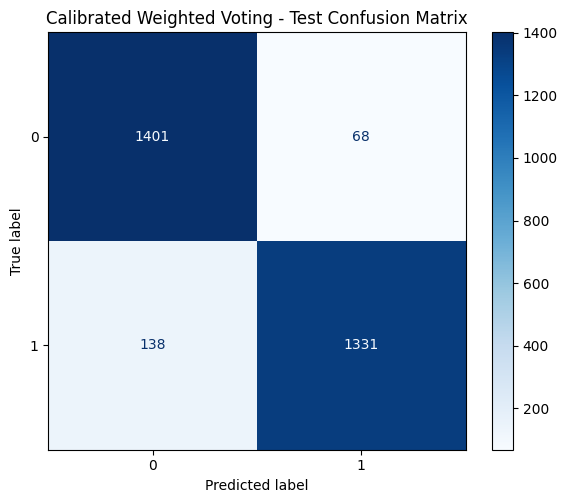

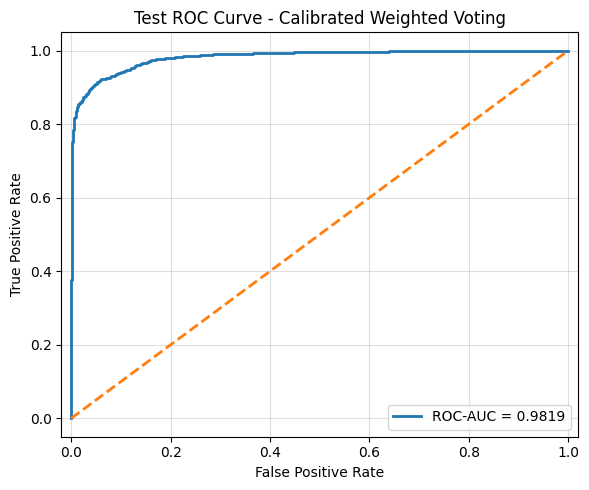

In [75]:

# ============================================================
# CELL 22: Plot final figures
# ============================================================

plot_confusion_figure(
    y_true=y_test,
    y_pred=ensemble_test_pred,
    title="Calibrated Weighted Voting - Test Confusion Matrix",
    save_path=OUTPUT_DIR / "ensemble_test_confusion_matrix.png"
)

plot_single_roc(
    y_true=y_test,
    y_prob=ensemble_test_prob,
    title="Test ROC Curve - Calibrated Weighted Voting",
    save_path=OUTPUT_DIR / "ensemble_test_roc_curve.png"
)





In [51]:
def plot_multi_roc(y_true, prob_dict, title, save_path):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    style_axis(ax)

    for model_name, y_prob in prob_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} = {roc_auc:.4f}")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



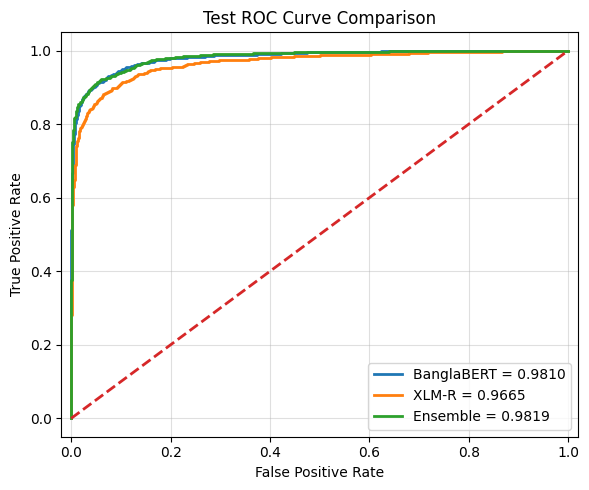

In [66]:
plot_multi_roc(
    y_true=y_test,
    prob_dict={
        "BanglaBERT": bangla_test_prob,
        "XLM-R": xlmr_test_prob,
        "Ensemble": ensemble_test_prob
    },
    title="Test ROC Curve Comparison",
    save_path=OUTPUT_DIR / "test_roc_curve_comparison.png"
)



In [53]:

def plot_multi_pr(y_true, prob_dict, title, save_path):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    style_axis(ax)

    for model_name, y_prob in prob_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        ax.plot(recall, precision, linewidth=2, label=f"{model_name} = {ap:.4f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

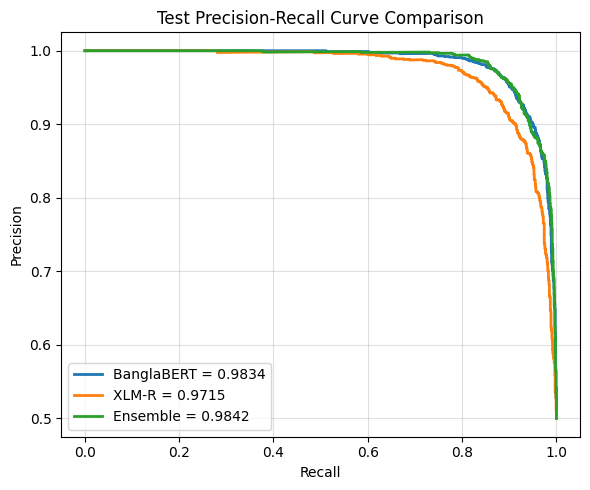

In [67]:
plot_multi_pr(
    y_true=y_test,
    prob_dict={
        "BanglaBERT": bangla_test_prob,
        "XLM-R": xlmr_test_prob,
        "Ensemble": ensemble_test_prob
    },
    title="Test Precision-Recall Curve Comparison",
    save_path=OUTPUT_DIR / "test_pr_curve_comparison.png"
)


In [50]:
def plot_calibration_comparison(y_true, prob_dict, title, save_path):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    style_axis(ax)

    for model_name, y_prob in prob_dict.items():
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label=model_name)

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect Calibration")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

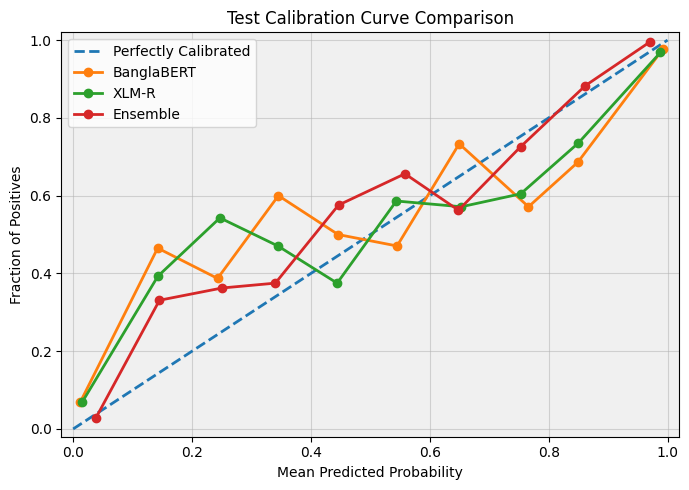

In [68]:
plot_calibration_comparison(
    y_true=y_test,
    prob_dict={
        "BanglaBERT": bangla_test_prob,
        "XLM-R": xlmr_test_prob,
        "Ensemble": ensemble_test_prob
    },
    title="Test Calibration Curve Comparison",
    save_path=OUTPUT_DIR / "test_calibration_curve_comparison.png"
)

,Model,Brier Score
0,BanglaBERT Raw,0.0595
1,BanglaBERT Calibrated,0.0553
2,XLM-R Raw,0.0741
3,XLM-R Calibrated,0.0694
4,Ensemble,0.0525


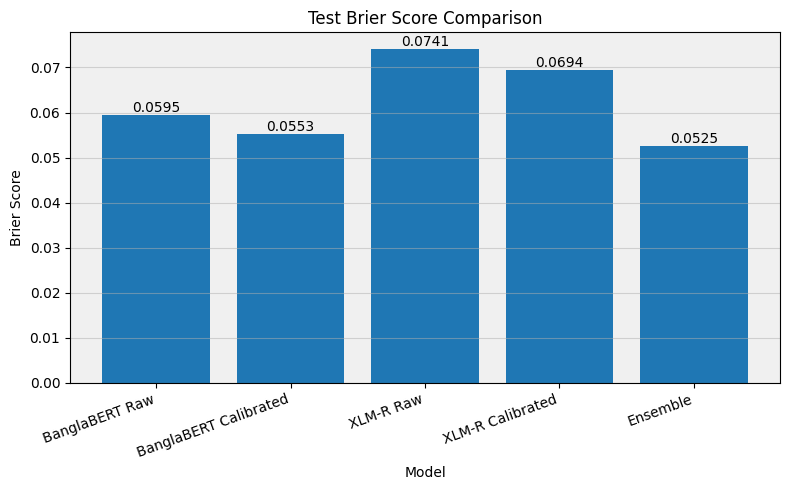

In [69]:
# ============================================================
# EXTRA CELL: Test Brier Score bar chart
# ============================================================

from sklearn.metrics import brier_score_loss

brier_data = pd.DataFrame({
    "Model": [
        "BanglaBERT Raw",
        "BanglaBERT Calibrated",
        "XLM-R Raw",
        "XLM-R Calibrated",
        "Ensemble"
    ],
    "Brier Score": [
        brier_score_loss(y_test, bangla_test_prob),
        brier_score_loss(y_test, bangla_test_prob_cal),
        brier_score_loss(y_test, xlmr_test_prob),
        brier_score_loss(y_test, xlmr_test_prob_cal),
        brier_score_loss(y_test, ensemble_test_prob)
    ]
}).round(4)

display(brier_data)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor("#f0f0f0")

bars = ax.bar(brier_data["Model"], brier_data["Brier Score"])

ax.set_xlabel("Model")
ax.set_ylabel("Brier Score")
ax.set_title("Test Brier Score Comparison")
ax.grid(True, axis="y", alpha=0.5)

plt.xticks(rotation=20, ha="right")

# Add value labels on top of bars
for bar, value in zip(bars, brier_data["Brier Score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_brier_score_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

brier_data.to_csv(OUTPUT_DIR / "test_brier_score_table.csv", index=False)

## Cell 23: Zip the output folder for download
This creates one zip file containing tables, logits, prediction files, and figures.

In [76]:
import os

for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print(file_name)

all_results_long_format.csv
banglabert_calibrated_test_confusion_matrix.png
banglabert_calibrated_test_roc_curve.png
banglabert_loss_curve.png
banglabert_test_confusion_matrix.png
banglabert_test_logits.npy
banglabert_test_predictions.csv
banglabert_test_prob.npy
banglabert_test_prob_calibrated.npy
banglabert_test_roc_curve.png
banglabert_val_logits.npy
banglabert_val_predictions.csv
banglabert_val_prob.npy
banglabert_val_prob_calibrated.npy
calibration_curve_comparison_full.png
calibration_info.json
ensemble_settings.json
ensemble_test_confusion_matrix.png
ensemble_test_predictions.csv
ensemble_test_prob.npy
ensemble_test_roc_curve.png
ensemble_val_predictions.csv
ensemble_val_prob.npy
ensemble_weight_threshold_search.csv
probability_quality_long_format.csv
test_brier_score_bar_chart.png
test_brier_score_table.csv
test_calibration_curve_comparison.png
test_pr_curve_comparison.png
test_results_long_format.csv
test_roc_curve_comparison.png
validation_results_long_format.csv
xlmr_calibra

In [77]:
# ============================================================
# CELL 23: Zip the final output folder
# ============================================================

print("Files saved in:", OUTPUT_DIR)
!cd /kaggle/working && zip -rq transformers_pipeline_outputs.zip final_outputs
print("Zip created:", "/kaggle/working/transformers_pipeline_outputs.zip")
FileLink('/kaggle/working/transformers_pipeline_outputs.zip')


Files saved in: /kaggle/working/final_outputs
Zip created: /kaggle/working/transformers_pipeline_outputs.zip


/kaggle/working/transformers_pipeline_outputs.zip